In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

**Read the data**

In [2]:
data_df = pd.read_csv('data.csv')

**Display the data**

In [3]:
data_df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,1/4/2023 0:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,8/23/2024 0:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2/27/2024 0:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,10/15/2023 0:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,5/8/2025 0:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,6/20/2024 0:00,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,3/4/2024 0:00,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,none,Facebook,1325.06
1197,ORD201197,7/13/2023 0:00,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,8/22/2024 0:00,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [5]:
data_df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [6]:
data_df['Date'] = pd.to_datetime(data_df['Date'])

In [7]:
data_df['TotalPrice'] = pd.to_numeric(data_df['TotalPrice'])

In [8]:
data_df['Year'] = data_df['Date'].dt.year

In [9]:
data_df['Month'] = data_df['Date'].dt.month_name

In [10]:
data_df['Quantity'].skew()

np.float64(0.027922314016614352)

The value above indicates that the data in the column is fairly symmetrical

In [11]:
data_df['UnitPrice'].skew()

np.float64(-0.026511641121850952)

The value above indicates that the data in the column is fairly symmetrical

In [12]:
data_df['ItemsInCart'].skew()

np.float64(0.0008767998521406929)

The value above indicates that the data in the column is fairly symmetrical

In [13]:
data_df['TotalPrice'].skew()

np.float64(0.8913590826809059)

The value above indicates the totalprice column has values that slightly increase(positive skew)

In [14]:
data_df['Quantity'].mode()

0    1
Name: Quantity, dtype: int64

In [15]:
data_df['UnitPrice'].mode()

0    127.18
1    133.39
2    136.84
3    183.67
4    228.91
5    466.42
6    629.34
Name: UnitPrice, dtype: float64

In [16]:
data_df['ItemsInCart'].mode()

0    5
Name: ItemsInCart, dtype: int64

In [17]:
data_df['TotalPrice'].mode()

0     211.14
1     367.34
2     410.52
3     635.90
4    2517.36
Name: TotalPrice, dtype: float64

In [18]:
data_df['Quantity'].median()

3.0

In [19]:
data_df['UnitPrice'].median()

364.21

In [20]:
data_df['ItemsInCart'].median()

5.0

In [21]:
data_df['TotalPrice'].median()

823.615

comparing the mode and median of a value can give a very good idea of the skew. For example that the quantity columns is skewed to the left because the most occuring value is less than the median value, so most people buy 1 item during a purchase 

In [22]:
data_df['Quantity'].var()

1.9812169863775424

In [23]:
data_df['UnitPrice'].var()

38878.82706832772

In [24]:
data_df['ItemsInCart'].var()

5.207447873227683

In [25]:
data_df['TotalPrice'].var()

672164.7762935207

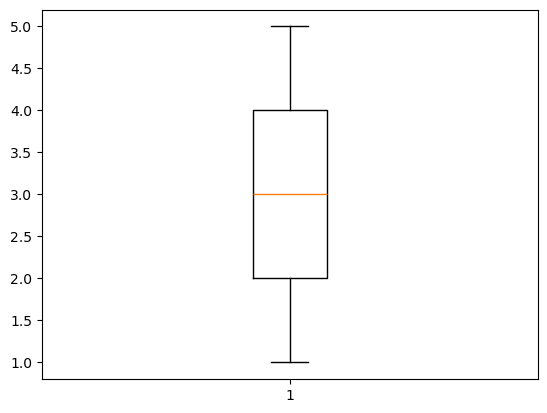

In [26]:
plt.boxplot(data_df['Quantity']);

The above boxplot shows normal symmetry with no suspected outliers

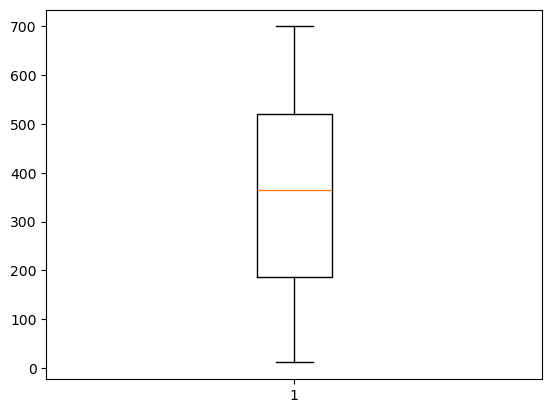

In [27]:
plt.boxplot(data_df['UnitPrice']);

The above boxplot shows normal symmetry with no suspected outliers

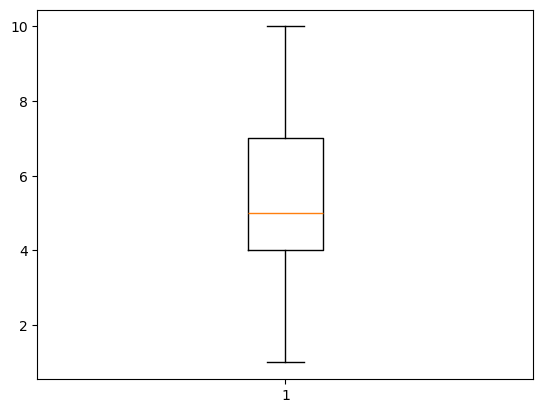

In [28]:
plt.boxplot(data_df['ItemsInCart']);

The above box plot show positively skewed data with the median less than 50% value of interquartile range

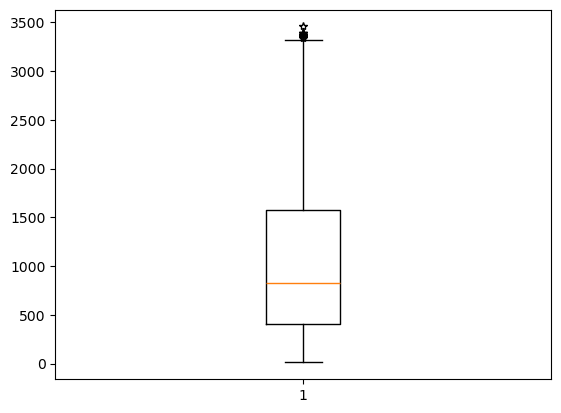

In [29]:
plt.boxplot(data_df['TotalPrice'], sym='*');

The above box plot show positively skewed data with suspected outliers, indicative of a possible fowlplay

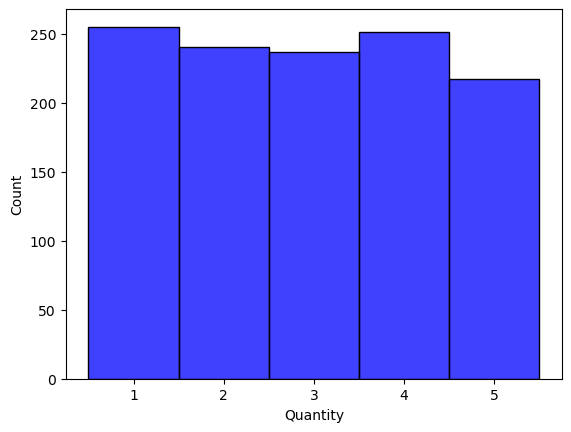

In [40]:
sns.histplot(data_df['Quantity'],discrete=True, stat='count', color='blue');

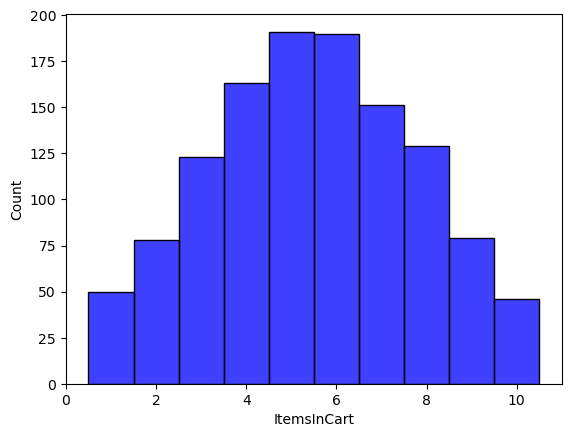

In [31]:
sns.histplot(data_df['ItemsInCart'],discrete=True, stat='count', color='blue');

In [32]:
IQR = 4-2

In [33]:
2 - (1.5*IQR)

-1.0

In [34]:
4 + (1.5*IQR) 

7.0

The outliers for quantity are values less than -1 and greater than 7

In [35]:
IQR = 7-4

In [36]:
4 - (1.5*IQR)

-0.5

In [37]:
7 + (1.5*IQR) 

11.5

The outliers for quantity are values less than -0.5 and greater than 11.5

In [38]:
def z_scores(colseries):
    mean = colseries.mean()
    std = colseries.std()
    
    for i in colseries:
        i = int(i)
        z = (i - mean)/(std)
        if z > 3 or z < -3 :
            print('value: ', i, '\n',z )


In [39]:
z_scores(data_df['Quantity'])

There are no outliers in any column based on z score